# **Profitable App Profiles for the App Store and Google Play**
You’re a data analyst for a company that builds free mobile apps. Revenue comes from in-app ads, so user volume is everything. Your job: identify which kinds of apps attract the most users on both the App Store and Google Play , using base Python, no pandas required.

*Step-by-Step Instructions:*

1.   Open both CSV files and explore each dataset.
2.   Remove duplicate entries and filter to free, English-language apps.
3.  Identify the most common genres on each platform.
4.  Identify which genres have the most users (installs or ratings as proxy).


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ramamet4/app-store-apple-data-set-10k-apps")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'app-store-apple-data-set-10k-apps' dataset.
Path to dataset files: /kaggle/input/app-store-apple-data-set-10k-apps


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lava18/google-play-store-apps")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'google-play-store-apps' dataset.
Path to dataset files: /kaggle/input/google-play-store-apps


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

1.

In [4]:
df1 = pd.read_csv('googleplaystore.csv')
df1.head(100)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,All of the parking lot - National Park applica...,AUTO_AND_VEHICLES,4.0,1754,14M,"500,000+",Free,0,Everyone,Auto & Vehicles,"June 2, 2018",2.3.4,4.0 and up
96,Inquiry Fines and Debits of Vehicles,AUTO_AND_VEHICLES,4.4,2680,2.2M,"500,000+",Free,0,Everyone,Auto & Vehicles,"March 20, 2018",1.03,4.0.3 and up
97,Gas Station,AUTO_AND_VEHICLES,4.0,1288,4.5M,"100,000+",Free,0,Everyone,Auto & Vehicles,"April 21, 2018",2.17,4.0 and up
98,Hush - Beauty for Everyone,BEAUTY,4.7,18900,17M,"500,000+",Free,0,Everyone,Beauty,"August 2, 2018",6.10.1,5.0 and up


In [5]:
df2 = pd.read_csv('AppleStore.csv')
df2.head(100)

,Unnamed: 0,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,1,281656475,PAC-MAN Premium,100788224,USD,3.99,21292,26,4.0,4.5,6.3.5,4+,Games,38,5,10,1
1,2,281796108,Evernote - stay organized,158578688,USD,0.00,161065,26,4.0,3.5,8.2.2,4+,Productivity,37,5,23,1
2,3,281940292,"WeatherBug - Local Weather, Radar, Maps, Alerts",100524032,USD,0.00,188583,2822,3.5,4.5,5.0.0,4+,Weather,37,5,3,1
3,4,282614216,"eBay: Best App to Buy, Sell, Save! Online Shop...",128512000,USD,0.00,262241,649,4.0,4.5,5.10.0,12+,Shopping,37,5,9,1
4,5,282935706,Bible,92774400,USD,0.00,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,108,306169895,Tozzle - Toddler's favorite puzzle,168192000,USD,2.99,2562,10,4.0,4.5,5.1,4+,Games,37,5,4,1
96,109,306257910,HomeBudget with Sync,17485824,USD,4.99,3042,6,3.5,4.0,3.3.0,4+,Finance,37,5,11,1
97,110,306375551,Wind Meter,5234688,USD,0.99,338,12,2.5,2.0,5.0,4+,Weather,43,0,1,1
98,111,306468004,Map My Run+ - GPS Running & Workout Tracker,237913088,USD,2.99,16434,3,4.5,4.5,17.5.5,4+,Health & Fitness,37,0,9,1


2.

In [6]:
df1.size

140933

In [7]:
df1_clean = df1.drop_duplicates()
df1_clean.size

134654

In [8]:
df2.size

122349

In [9]:
df2_clean = df2.drop_duplicates()
df2_clean.size

122349

In [10]:
df1_clean = df1_clean[df1_clean['Type'] == 'Free']
df1_clean.size

124683

In [11]:
def is_english(name):
    non_ascii = sum(1 for ch in name if ord(ch) > 127)
    return non_ascii <= 3
df1_clean = df1_clean[df1_clean['App'].apply(is_english)]
df2_clean = df2_clean[df2_clean['track_name'].apply(is_english)]

In [12]:
df1_clean.size

124150

In [13]:
df2_clean.size

105111

3.

In [14]:
df2_clean = df2_clean.reset_index(drop=True).copy()

In [15]:
gs_df2 = (df2_clean.groupby('prime_genre').agg(n_apps=("track_name", "count"),
         total_ratings=("rating_count_tot", "sum"))
    .sort_values("total_ratings", ascending=False))

In [16]:
gs_df2.head(10)

,n_apps,total_ratings
prime_genre,,
Games,3392,52870288
Social Networking,126,7591985
Photo & Video,341,5008852
Music,137,3979454
Entertainment,449,3979222
Shopping,85,2263976
Health & Fitness,165,1782356
Utilities,213,1688563
Weather,69,1597022


In [17]:
print("'",gs_df2.index[0],"'", 'is the most common genre')

' Games ' is the most common genre


In [18]:
df1_clean = df1_clean.reset_index(drop=True).copy()

In [19]:
gs_df1 = df1_clean["Genres"].str.get_dummies(sep=";")
gs_df1.head()

,Action,Action & Adventure,Adventure,Arcade,Art & Design,Auto & Vehicles,Beauty,Board,Books & Reference,Brain Games,...,Simulation,Social,Sports,Strategy,Tools,Travel & Local,Trivia,Video Players & Editors,Weather,Word
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
gs_df1_cout = gs_df1.sum().sort_values(ascending=False)
gs_df1_cout.head(10)

,0
Tools,764
Entertainment,605
Education,605
Business,414
Productivity,378
Lifestyle,351
Action,344
Finance,343
Sports,342
Communication,339


In [21]:
print("'", gs_df1_cout.index[0], "'", 'is the most common genre')

' Tools ' is the most common genre


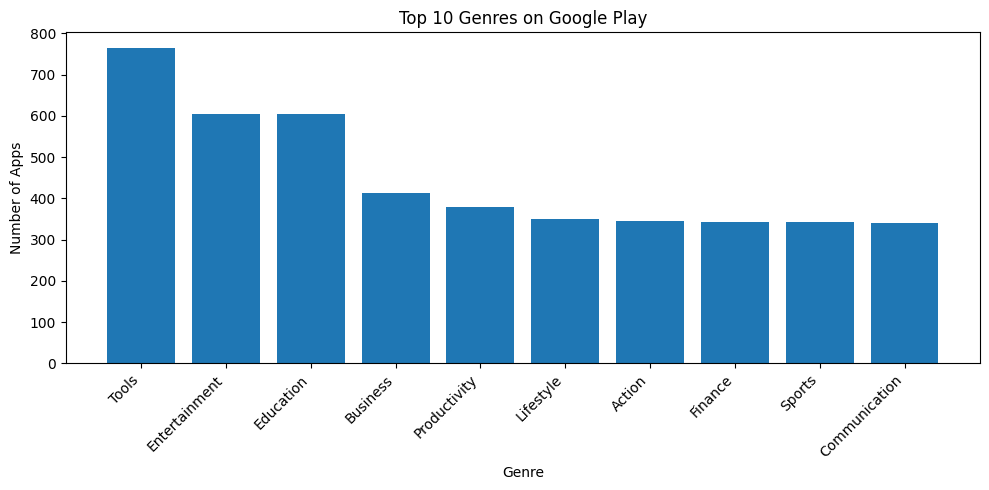

In [22]:
top_genres = gs_df1_cout.head(10)
plt.figure(figsize=(10, 5))
plt.bar(top_genres.index, top_genres.values, width=0.8, align='center')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Genres on Google Play')
plt.ylabel('Number of Apps')
plt.xlabel('Genre')
plt.tight_layout()
plt.show()

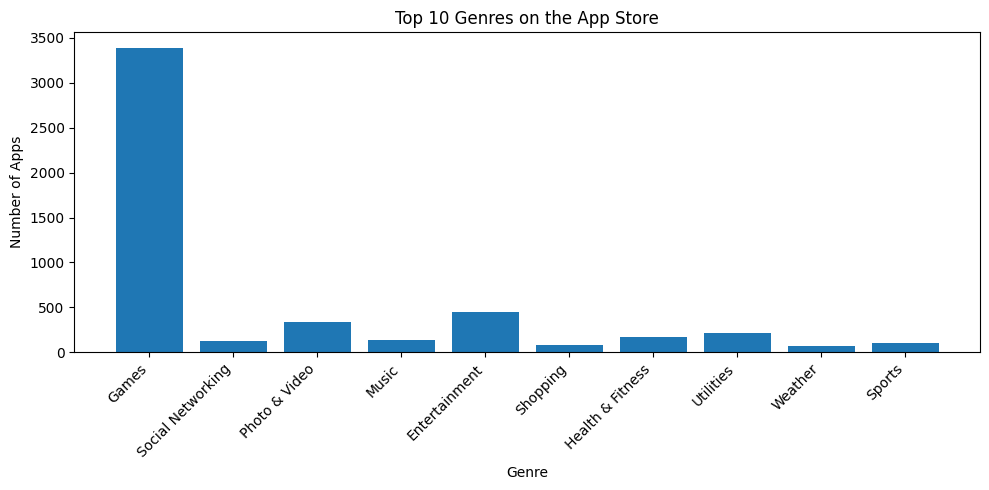

In [23]:
top_genres2 = gs_df2.head(10)
plt.figure(figsize=(10, 5))
plt.bar(top_genres2.index, top_genres2['n_apps'], width=0.8, align='center')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Genres on the App Store')
plt.ylabel('Number of Apps')
plt.xlabel('Genre')
plt.tight_layout()
plt.show()

4.

In [24]:
df2_mosUser = df2_clean.groupby("prime_genre")["rating_count_tot"].sum()
df2_mosUser = df2_mosUser.sort_values(ascending=False)
df2_mosUser.head(10)

,rating_count_tot
prime_genre,
Games,52870288
Social Networking,7591985
Photo & Video,5008852
Music,3979454
Entertainment,3979222
Shopping,2263976
Health & Fitness,1782356
Utilities,1688563
Weather,1597022


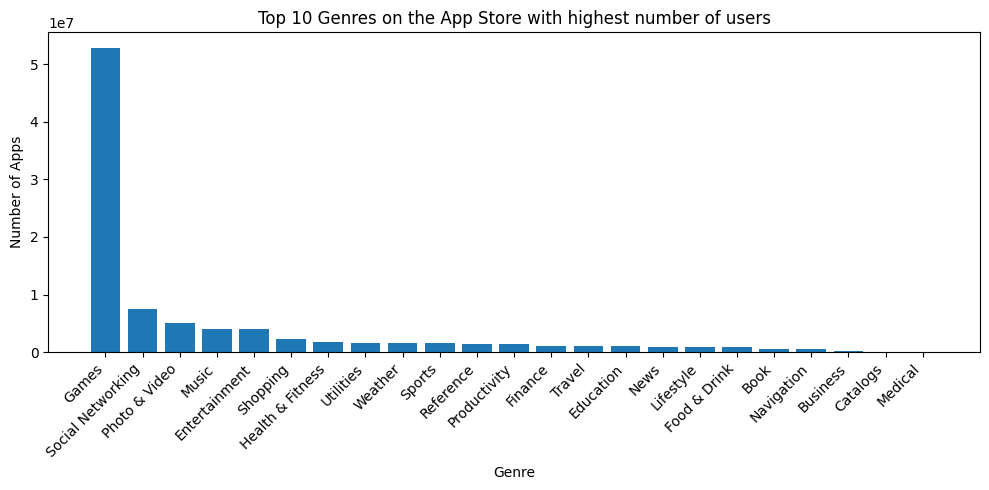

In [25]:
plt.figure(figsize=(10, 5))
plt.bar(df2_mosUser.index, df2_mosUser.values, width=0.8, align='center')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Genres on the App Store with highest number of users')
plt.ylabel('Number of Apps')
plt.xlabel('Genre')
plt.tight_layout()
plt.show()

In [26]:
print("'",df2_mosUser.index[0],"'", 'has the highest number of users')

' Games ' has the highest number of users


In [27]:
df1_clean['Installs_numeric'] = df1_clean['Installs'].str.replace('+', '', regex=False).str.replace(',', '', regex=False).astype(float)
df1_mosUser = df1_clean.groupby("Genres")["Installs_numeric"].sum()
df1_mosUser = df1_mosUser.sort_values(ascending=False)
df1_mosUser.head(10)

,Installs_numeric
Genres,
Communication,2.415091e+10
Social,1.251386e+10
Productivity,1.246163e+10
Tools,1.144104e+10
Photography,9.719269e+09
Arcade,9.715692e+09
Casual,8.662799e+09
Action,8.318987e+09
Travel & Local,6.361604e+09


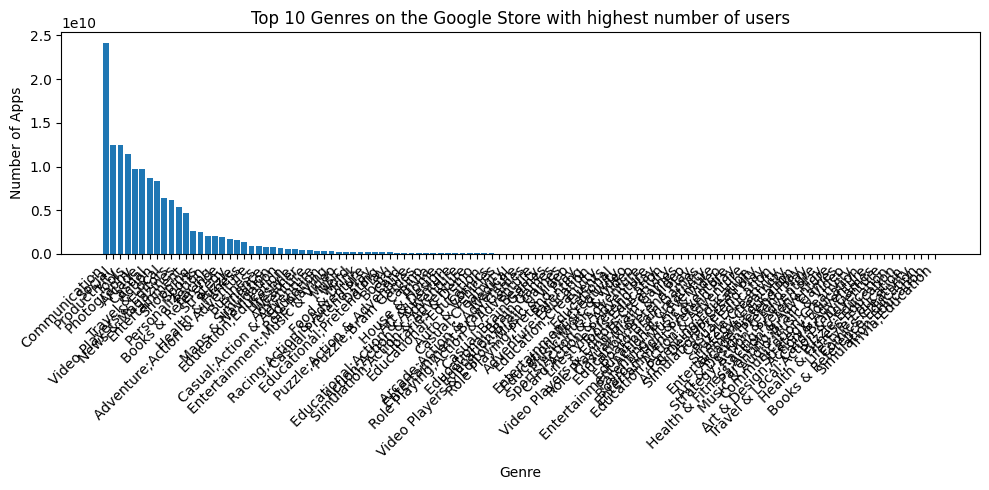

In [28]:
plt.figure(figsize=(10, 5))
plt.bar(df1_mosUser.index, df1_mosUser.values, width=0.8, align='center')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Genres on the Google Store with highest number of users')
plt.ylabel('Number of Apps')
plt.xlabel('Genre')
plt.tight_layout()
plt.show()

In [29]:
print("'",df1_mosUser.index[0],"'", 'has the highest number of users')

' Communication ' has the highest number of users
